# LAB 04: KEYPOINT DETECTION


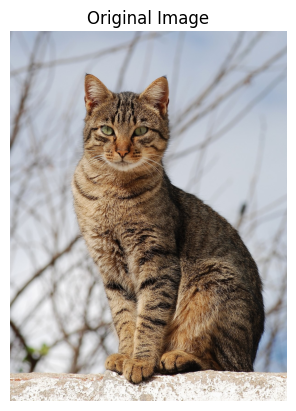

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as An

img = cv2.imread('cat.jpg')
img2 = cv2.imread('dog.jpg')

def show_img(image, title='Image'):
    if len(image.shape) == 3:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        image_rgb = image
    An.imshow(image_rgb, cmap='gray' if len(image.shape) == 2 else None)
    An.title(title)
    An.axis('off')
    An.show()

if img is not None:
    show_img(img, "Original Image")

## 1. Harris Corner Detection


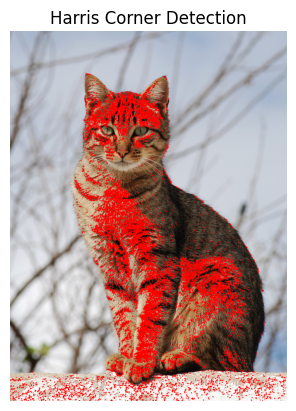

In [2]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)
    dst = cv2.dilate(dst, None)
    img_harris = img.copy()
    img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]
    show_img(img_harris, 'Harris Corner Detection')

## 2. Band-pass filtering by Difference of Gaussians (DoG)

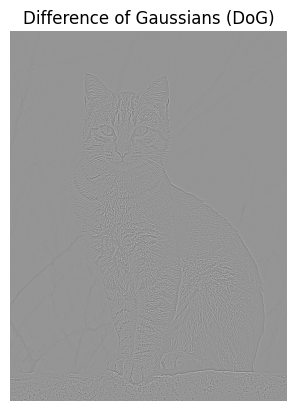

In [3]:
if img is not None:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur1 = cv2.GaussianBlur(gray_img, (5, 5), 1.0)
    blur2 = cv2.GaussianBlur(gray_img, (9, 9), 2.0)
    dog = blur1.astype(np.float32) - blur2.astype(np.float32)
    dog_norm = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    show_img(dog_norm, 'Difference of Gaussians (DoG)')

## 3. Scale Selection & Blob Detection qua thuật toán SIFT


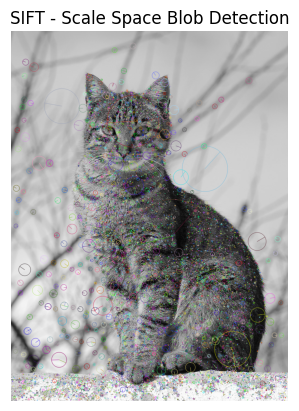

In [4]:
if img is not None:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray_img, None)
    img_sift = cv2.drawKeypoints(gray_img, keypoints, img.copy(), 
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    show_img(img_sift, 'SIFT - Scale Space Blob Detection')

## 4. Bag-of-words Detection & CBIR


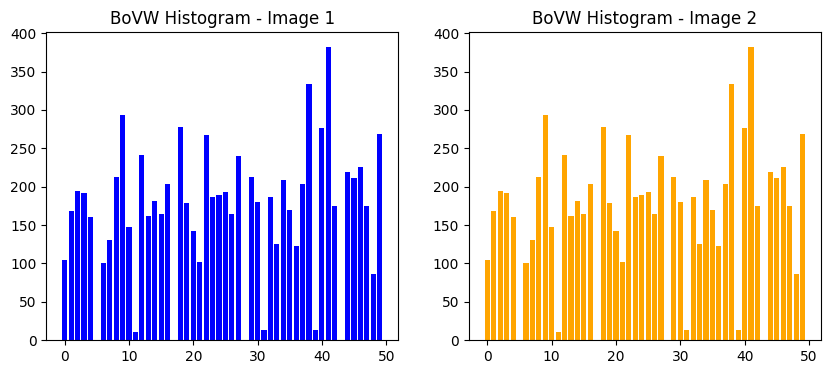

In [5]:
if img is not None and img2 is not None:
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = sift.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)
    if des1 is not None and des2 is not None:
        all_descriptors = np.vstack((des1, des2)).astype(np.float32)
        dictionarySize = 50
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 0.1)
        flags = cv2.KMEANS_RANDOM_CENTERS
        compactness, labels, centers = cv2.kmeans(all_descriptors, dictionarySize, None, criteria, 10, flags)
        def compute_bovw_histogram(descriptors, vocabulary):
            histogram = np.zeros(len(vocabulary))
            if descriptors is not None:
                for des in descriptors:
                    distances = np.linalg.norm(vocabulary - des, axis=1)
                    nearest_word_idx = np.argmin(distances)
                    histogram[nearest_word_idx] += 1
            return histogram
        hist1 = compute_bovw_histogram(np.float32(des1), centers)
        hist2 = compute_bovw_histogram(np.float32(des2), centers)
        An.figure(figsize=(10, 4))
        An.subplot(1, 2, 1)
        An.bar(range(dictionarySize), hist1, color='blue')
        An.title("BoVW Histogram - Image 1")
        An.subplot(1, 2, 2)
        An.bar(range(dictionarySize), hist2, color='orange')
        An.title("BoVW Histogram - Image 2")
        An.show()

## 5. Image Panoramas & Automatic Mosaicing


In [6]:
if img is not None and img2 is not None:
    stitcher = cv2.Stitcher_create()
    status, pano = stitcher.stitch([img, img2])
    if status == cv2.Stitcher_OK:
        show_img(pano, 'Panorama / Auto Mosaicing Result')
    else:
        print("Lỗi ghép ảnh Panorama/Mosaicing (thường do không đủ điểm chung giữa 2 ảnh)")

Lỗi ghép ảnh Panorama/Mosaicing (thường do không đủ điểm chung giữa 2 ảnh)


## 6. Wide Base-line Stereo (Feature Matching)


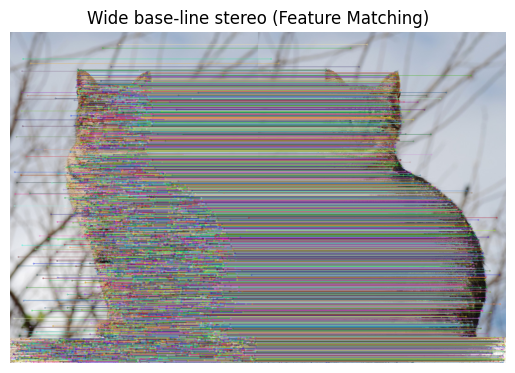

In [7]:
if img is not None and img2 is not None:
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = sift.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)
    if des1 is not None and des2 is not None:
        FLANN_INDEX_KDTREE = 1
        index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        if len(des1) >= 2 and len(des2) >= 2:
            matches = flann.knnMatch(des1, des2, k=2)
            good_matches = []
            for match in matches:
                if len(match) == 2:
                    m, n = match
                    if m.distance < 0.75 * n.distance:
                        good_matches.append(m)
            img_matches = cv2.drawMatches(img, kp1, img2, kp2, good_matches, None, 
                                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
            show_img(img_matches, 'Wide base-line stereo (Feature Matching)')